# 02 · Índices FAISS, recuperación y reranking

Lee los chunks y vectores elegidos por el notebook 01. Si no existen, genera una configuración de arranque (`jerarquico` + TF-IDF) para poder ejecutarse de forma independiente; para una decisión real, ejecutar primero 01. **Decoder** aquí significa etapa de recuperación que entrega evidencia al generador; el cross-encoder es un reranker, no un modelo generativo.

Instalar también `faiss-cpu`. Los índices aproximados en ~20 documentos solo ilustran el método; comparar latencia y recall ANN en el corpus real. Las consultas `dev` eligen la canalización; `test` se usa una única vez al final.

In [1]:
from pathlib import Path
import sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

HERE = Path.cwd() / "notebooks" if (Path.cwd() / "notebooks/lab_core.py").exists() else Path.cwd()
if not (HERE / "lab_core.py").exists():
    raise FileNotFoundError("Ejecuta desde la raíz de rag-derecho-colombiano o desde notebooks/")
sys.path.insert(0, str(HERE))
import lab_core as lab
data = lab.load_sample()
docs, queries = data["documents"], data["queries"]
dev = [q for q in queries if q["split"] == "dev"]
test = [q for q in queries if q["split"] == "test"]
print(f"{len(docs)} artículos, {len(dev)} consultas dev, {len(test)} test")

20 artículos, 19 consultas dev, 13 test


In [2]:
import faiss
out = HERE / "artefactos_lab"
saved_config = json.loads((out / "config.json").read_text(encoding="utf-8")) if (out / "config.json").exists() else {}
if (out / "vectors.npz").exists() and any(name != "tfidf" for name in saved_config.get("evaluated_encoders", [])):
    config = json.loads((out / "config.json").read_text(encoding="utf-8"))
    chunks = json.loads((out / "chunks.json").read_text(encoding="utf-8"))
    loaded = np.load(out / "vectors.npz")
    x, qv = loaded["documents"], loaded["queries"]
else:
    config = {"strategy": "jerarquico", "encoder": "tfidf", "origen": "arranque_independiente"}
    chunks = lab.make_chunks(docs, config["strategy"])
    enc = lab.Encoder(config["encoder"])
    x = enc.fit_documents([c["indexed_text"] for c in chunks])
    qv = enc.queries([q["question"] for q in queries])
x, qv = np.ascontiguousarray(x, dtype="float32"), np.ascontiguousarray(qv, dtype="float32")
assert x.shape[0] == len(chunks) and qv.shape[0] == len(queries)
assert len({c["chunk_id"] for c in chunks}) == len(chunks)
faiss.normalize_L2(x); faiss.normalize_L2(qv)
display(config); print(x.shape, qv.shape)

{'strategy': 'oraciones',
 'encoder': 'intfloat/multilingual-e5-base',
 'evaluated_encoders': ['tfidf', 'intfloat/multilingual-e5-base'],
 'n_docs': 20,
 'n_chunks': 45}

(45, 768) (32, 768)


## 1. Índices exactos y aproximados

`FlatIP` es la referencia exacta (producto interno = coseno por normalización). `FlatL2` debe producir el mismo orden salvo empates. `IVFFlat` entrena centroides y varía `nprobe`; `HNSW` varía `efSearch`. El ID retornado por FAISS es la fila de `chunks`; **FAISS no almacena la cita ni la categoría**. Se mide recall de vecinos contra FlatIP, Recall@3 de artículos, memoria serializada y mediana de latencia de búsqueda. El tiempo de codificar la consulta se evalúa aparte en 01.

,índice,vecinos@10_vs_FlatIP,latencia_búsqueda_ms,índice_MiB,recall@1,recall@3,recall@5,mrr@5,ndcg@5
0,FlatIP,1.0000,0.0090,0.1319,0.6842,0.8684,0.9737,0.7930,0.8338
1,FlatL2,1.0000,0.0082,0.1319,0.6842,0.8684,0.9737,0.7930,0.8338
2,IVF nprobe=1,0.5211,0.0126,0.1499,0.4737,0.6316,0.7632,0.5807,0.6233
3,IVF nprobe=4,0.9895,0.0105,0.1499,0.6842,0.8684,0.9737,0.7930,0.8338
4,IVF nprobe=6,1.0000,0.0098,0.1499,0.6842,0.8684,0.9737,0.7930,0.8338
5,HNSW ef=16,0.9895,0.0047,0.1383,0.6842,0.8684,0.9737,0.7930,0.8338
6,HNSW ef=48,1.0000,0.0059,0.1383,0.6842,0.8684,0.9737,0.7930,0.8338


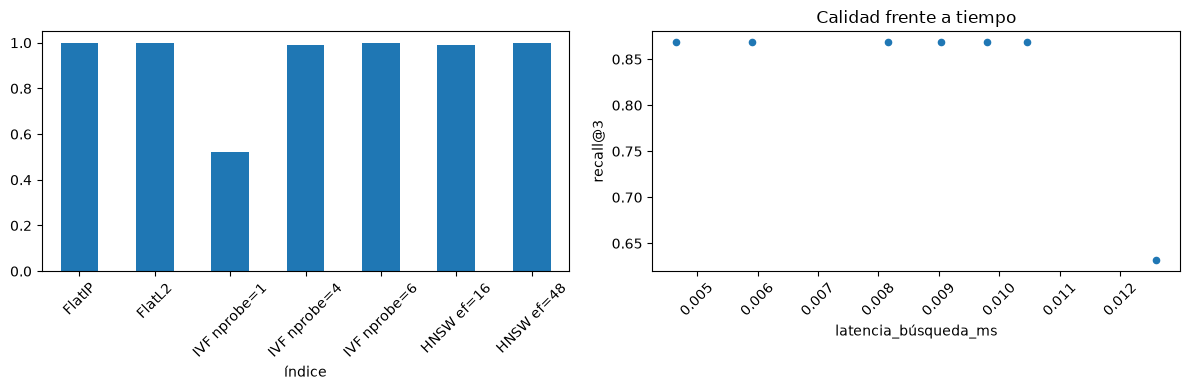

In [3]:
n, dim = x.shape
flat = faiss.IndexFlatIP(dim); flat.add(x)
l2 = faiss.IndexFlatL2(dim); l2.add(x)
indices = {"FlatIP": flat, "FlatL2": l2}
nlist = max(2, min(8, int(np.sqrt(n))))
ivf = faiss.IndexIVFFlat(faiss.IndexFlatIP(dim), dim, nlist, faiss.METRIC_INNER_PRODUCT)
ivf.train(x); ivf.add(x)
for probes in sorted({1, min(4, nlist), nlist}):
    clone = faiss.deserialize_index(faiss.serialize_index(ivf))
    clone.nprobe = probes
    indices[f"IVF nprobe={probes}"] = clone
hnsw = faiss.IndexHNSWFlat(dim, 16, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 40; hnsw.add(x)
for ef in (16, 48):
    clone = faiss.deserialize_index(faiss.serialize_index(hnsw))
    clone.hnsw.efSearch = ef
    indices[f"HNSW ef={ef}"] = clone
dev_pos = [i for i, q in enumerate(queries) if q["split"] == "dev"]
test_pos = [i for i, q in enumerate(queries) if q["split"] == "test"]
exact_ids = flat.search(qv[dev_pos], min(10, n))[1]
index_rows = []
for name, index in indices.items():
    _, ids = index.search(qv[dev_pos], n)
    ann_recall = np.mean([len(set(a).intersection(b[:len(a)])) / len(a) for a, b in zip(exact_ids, ids)])
    index_rows.append({"índice": name, "vecinos@10_vs_FlatIP": ann_recall,
                       "latencia_búsqueda_ms": lab.timed_search(index, qv[dev_pos], min(10, n)),
                       "índice_MiB": len(faiss.serialize_index(index)) / 2**20,
                       **lab.metrics(ids, chunks, dev)})
index_table = pd.DataFrame(index_rows)
display(index_table.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
index_table.plot.bar(x="índice", y="vecinos@10_vs_FlatIP", ax=axes[0], legend=False, ylim=(0, 1.05))
index_table.plot.scatter(x="latencia_búsqueda_ms", y="recall@3", ax=axes[1], title="Calidad frente a tiempo")
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 2. Clasificación, BM25, fusión y agregación

Se prueban búsqueda densa, BM25 y RRF; luego un filtro de categoría **previo** a la búsqueda. El clasificador por reglas puede fallar, así que `None` busca globalmente y se muestra su exactitud por consulta. Las consultas con cita explícita se pueden enrutar por norma y artículo verificados; aquí se evita usar el `doc_id` verdadero como atajo. Se deduplican documentos por el primer chunk (equivalente a max pooling del puntaje si el ranking se ordena por puntaje).

In [4]:
K_CANDIDATOS = min(30, n)
dense = [list(map(int, row)) for row in flat.search(qv, n)[1]]
lexical = lab.bm25_rank(chunks, [q["question"] for q in queries], n)
hybrid = lab.rrf(dense, lexical, n)

def category_rank(i, fallback=True):
    label = lab.classify_query(queries[i]["question"])
    if label is None: return dense[i]
    subset = np.array([j for j, c in enumerate(chunks) if c["category"] == label], dtype=int)
    if len(subset) == 0: return dense[i] if fallback else []
    # Se restringe el universo ANTES de puntuar; en FAISS grande usar IDSelector
    # o índices separados por categoría.
    scores = x[subset] @ qv[i]
    return subset[np.argsort(-scores, kind="stable")].tolist()

filtered = [category_rank(i) for i in range(len(queries))]
query_categories = pd.DataFrame([{"consulta": q["query_id"], "predicha": lab.classify_query(q["question"]),
                                  "real": lab.category(next(d for d in docs if d["doc_id"] == q["relevant_doc_ids"][0]))}
                                 for q in queries])
display(query_categories)
print("Exactitud de clasificación en dev:", np.mean((query_categories.iloc[dev_pos].predicha == query_categories.iloc[dev_pos].real)))
pipelines = {"denso": dense, "BM25": lexical, "RRF": hybrid, "denso+categoría": filtered}
pipeline_rows = []
for name, ranks in pipelines.items():
    pipeline_rows.append({"pipeline": name, **lab.metrics([ranks[i] for i in dev_pos], chunks, dev)})
pipeline_table = pd.DataFrame(pipeline_rows)
display(pipeline_table.round(3))

,consulta,predicha,real
0,q01,fundamentos,fundamentos
1,q02,fundamentos,fundamentos
2,q03,fundamentos,fundamentos
3,q04,fundamentos,fundamentos
4,q05,datos_especiales,datos_especiales
5,q06,datos_especiales,datos_especiales
6,q07,datos_especiales,datos_especiales
7,q08,derechos_tramites,derechos_tramites
8,q09,derechos_tramites,derechos_tramites
9,q10,derechos_tramites,derechos_tramites


Exactitud de clasificación en dev: 0.631578947368421


,pipeline,recall@1,recall@3,recall@5,mrr@5,ndcg@5
0,denso,0.684,0.868,0.974,0.793,0.834
1,BM25,0.421,0.579,0.763,0.544,0.596
2,RRF,0.632,0.868,0.868,0.763,0.785
3,denso+categoría,0.579,0.763,0.868,0.688,0.729


## 3. Cross-encoder en candidatos

El reranker recibe pares `(consulta, chunk)` y reordena solo los primeros candidatos del recuperador. Activarlo descarga el modelo multilingüe [mMARCO MiniLM](https://huggingface.co/cross-encoder/mmarco-mMiniLMv2-L12-H384-v1). Se deja apagado por defecto para que el laboratorio básico sea ejecutable sin esa descarga. **No** comparar scores crudos de modelos diferentes; comparar rankings. Si un artículo relevante no llega a los candidatos, el reranker no lo puede rescatar.

In [ ]:
ACTIVAR_CROSS_ENCODER = False
RERANK_MODEL = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"
if ACTIVAR_CROSS_ENCODER:
    from sentence_transformers import CrossEncoder
    cross = CrossEncoder(RERANK_MODEL, max_length=512)
    def rerank(query, ranking, k=K_CANDIDATOS):
        candidates = list(ranking[:k])
        pairs = [(query, chunks[j]["indexed_text"]) for j in candidates]
        scores = cross.predict(pairs, batch_size=16)
        return [candidates[j] for j in np.argsort(-np.asarray(scores), kind="stable")] + list(ranking[k:])
    t0 = time.perf_counter()
    pipelines["RRF+cross"] = [rerank(q["question"], ranking) for q, ranking in zip(queries, hybrid)]
    rerank_ms = (time.perf_counter() - t0) * 1000 / len(queries)
    print(f"Reranking: {rerank_ms:.1f} ms/consulta, además de búsqueda y encoder")
    pipeline_table = pd.DataFrame([{"pipeline": name, **lab.metrics([ranks[i] for i in dev_pos], chunks, dev)} for name, ranks in pipelines.items()])
    display(pipeline_table.round(3))
else:
    print("Cross-encoder desactivado. Actívalo para comparar calidad y latencia reales.")

Cross-encoder desactivado. Actívalo para comparar calidad y latencia reales.


## 4. Elegir en desarrollo y abrir la prueba una vez

El criterio predefinido es 60 % Recall@3 y 40 % MRR@5 en `dev`. Los resultados de `test` son una estimación muy ruidosa (13 consultas). Reportar además fallos por pregunta y distinguir errores de extracción, chunking, candidato, categoría y reranking. En producción también medir P50/P95 con concurrencia, coste de memoria, actualización de índices y evaluación por norma y dominio.

Pipeline elegido en dev: denso


,recall@1,recall@3,recall@5,mrr@5,ndcg@5
0,0.923,0.923,0.923,0.923,0.923


,consulta,pregunta,relevante,top3,acierto@3
0,q03,¿Qué significa dato personal y quién es el enc...,art03,"[art03, art08, art14]",True
1,q05,"¿Qué datos se consideran sensibles, incluidos ...",art05,"[art05, art06, art18]",True
2,q08,"¿Qué derechos tiene el titular para conocer, a...",art08,"[art08, art01, art15]",True
3,q10,¿Cuándo no es necesaria la autorización del ti...,art10,"[art10, art09, art12]",True
4,q13,¿A quiénes se les puede suministrar informació...,art13,"[art13, art11, art02]",True
5,q15,¿Cómo se presentan los reclamos de corrección ...,art15,"[art15, art08, art18]",True
6,q18,¿Cuáles son los deberes del encargado del trat...,art18,"[art18, art17, art12]",True
7,q20,¿Con qué recursos cuenta la Superintendencia p...,art20,"[art20, art19, art18]",True
8,q21,¿Puede quedar fuera del régimen una agenda de ...,art02,"[art02, art04, art14]",True
9,q24,Encontré un dato equivocado sobre mí en una ba...,art08,"[art15, art02, art01]",False


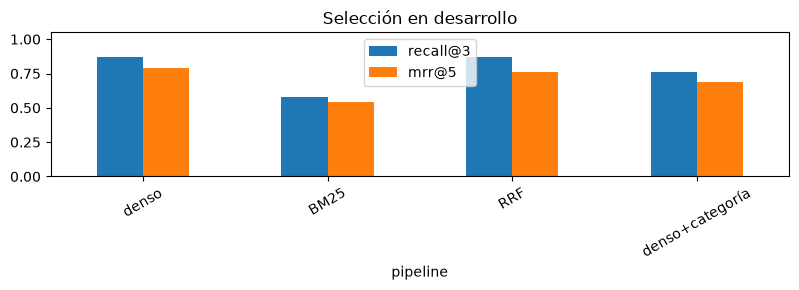

Resultados guardados en C:\Users\nrir\Desktop\dev\AI WEEK\rag-derecho-colombiano\notebooks\artefactos_lab


In [6]:
pipeline_table["utilidad_dev"] = .6 * pipeline_table["recall@3"] + .4 * pipeline_table["mrr@5"]
selected_name = pipeline_table.sort_values(["utilidad_dev", "pipeline"], ascending=[False, True]).iloc[0]["pipeline"]
selected = pipelines[selected_name]
test_result = lab.metrics([selected[i] for i in test_pos], chunks, test)
print("Pipeline elegido en dev:", selected_name)
display(pd.DataFrame([test_result]).round(3))
failures = []
for i in test_pos:
    top = lab.dedupe_documents(selected[i], chunks, 3)
    retrieved = [chunks[j]["doc_id"] for j in top]
    failures.append({"consulta": queries[i]["query_id"], "pregunta": queries[i]["question"],
                     "relevante": queries[i]["relevant_doc_ids"][0], "top3": retrieved,
                     "acierto@3": queries[i]["relevant_doc_ids"][0] in retrieved})
display(pd.DataFrame(failures))
fig, ax = plt.subplots(figsize=(8, 3))
pipeline_table.plot.bar(x="pipeline", y=["recall@3", "mrr@5"], ax=ax, ylim=(0, 1.05), title="Selección en desarrollo")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
out.mkdir(exist_ok=True)
pd.DataFrame(failures).to_json(out / "errores_test.json", orient="records", force_ascii=False, indent=2)
index_table.to_csv(out / "comparacion_indices_dev.csv", index=False)
pipeline_table.to_csv(out / "comparacion_retrieval_dev.csv", index=False)
print("Resultados guardados en", out)

## 5. Paso al corpus completo

1. Congelar manifiestos por fuente, hash, fecha, licencia y vigencia comprobada. Extraer PDF/HTML con validación de orden de lectura, tablas y OCR; mantener coordenadas/offsets citables.
2. Construir juicios de relevancia con varias normas, áreas y preguntas sin respuesta. Reservar `test` por documento o norma para reducir fuga; usar varios juicios por pregunta si existen artículos complementarios.
3. Repetir el barrido de chunking y encoder con el tokenizador real y presupuesto de memoria. Inspeccionar visualmente chunks largos, huérfanos, duplicados y fragmentos que separan excepción de regla.
4. Recalibrar FAISS con el número real de vectores y separar tiempo de embedding, búsqueda y reranking. Comprobar ANN recall contra FlatIP. Versionar encoder, normalización, índice y mapeo fila→chunk juntos.
5. Escoger con `dev`; ejecutar `test` una sola vez y pasar los pasajes recuperados al generador con citas y abstención. No inferir calidad de respuesta solo desde Recall de recuperación.